# Clean Training Loops with Callbacks

Once experiments move beyond a single notebook cell, training code gets messy quickly. The goal here is not to hide PyTorch behind a framework. The goal is to keep the mechanics visible while separating responsibilities:

- the model does modeling
- the optimizer updates parameters
- the training loop coordinates epochs and batches
- callbacks handle side effects such as checkpointing or early stopping

This is the same idea as larger workflow libraries, but implemented in plain PyTorch so you can see every moving part.


In [1]:
import math
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, random_split

torch.manual_seed(3)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint_dir = Path('checkpoints_native')
checkpoint_dir.mkdir(exist_ok=True)
print(f'Using device: {device}')


Using device: cpu


In [2]:
class StormPatchDataset(Dataset):
    def __init__(self, n_samples=3000, size=32):
        self.n_samples = n_samples
        self.size = size
        x = torch.linspace(-1.0, 1.0, size)
        self.xx, self.yy = torch.meshgrid(x, x, indexing='ij')

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        gen = torch.Generator().manual_seed(idx)
        cx = torch.empty(1).uniform_(-0.7, 0.7, generator=gen).item()
        cy = torch.empty(1).uniform_(-0.7, 0.7, generator=gen).item()
        width = torch.empty(1).uniform_(0.15, 0.3, generator=gen).item()
        blob = torch.exp(-((self.xx - cx) ** 2 + (self.yy - cy) ** 2) / (2 * width ** 2))
        wave = 0.15 * torch.sin(math.pi * 2 * self.xx) + 0.15 * torch.cos(math.pi * self.yy)
        field = (blob + wave).float()[None, ...]
        label = torch.tensor(int(cx > 0.0), dtype=torch.long)
        return field, label


full_dataset = StormPatchDataset()
train_set, val_set = random_split(full_dataset, [2400, 600], generator=torch.Generator().manual_seed(0))
train_loader = DataLoader(train_set, batch_size=64, shuffle=True, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_set, batch_size=128, shuffle=False, pin_memory=torch.cuda.is_available())


class SmallStormCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(16 * 8 * 8, 32),
            nn.ReLU(),
            nn.Linear(32, 2),
        )

    def forward(self, x):
        return self.net(x)


In [3]:
@dataclass
class State:
    model: nn.Module
    optimizer: torch.optim.Optimizer
    scheduler: object | None
    device: torch.device
    epoch: int = 0
    stop_training: bool = False
    history: dict = field(default_factory=lambda: {'train_loss': [], 'val_loss': [], 'val_accuracy': [], 'weight_norm': []})
    best_val_loss: float = float('inf')


class Callback:
    def on_epoch_end(self, state, metrics):
        pass


class HistoryCallback(Callback):
    def on_epoch_end(self, state, metrics):
        for key in ['train_loss', 'val_loss', 'val_accuracy', 'weight_norm']:
            state.history[key].append(metrics[key])


class EarlyStopping(Callback):
    def __init__(self, patience=3, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best = float('inf')
        self.bad_epochs = 0

    def on_epoch_end(self, state, metrics):
        current = metrics['val_loss']
        if current < self.best - self.min_delta:
            self.best = current
            self.bad_epochs = 0
        else:
            self.bad_epochs += 1
            if self.bad_epochs >= self.patience:
                state.stop_training = True


class CheckpointSaver(Callback):
    def __init__(self, path):
        self.path = Path(path)

    def on_epoch_end(self, state, metrics):
        if metrics['val_loss'] < state.best_val_loss:
            state.best_val_loss = metrics['val_loss']
            torch.save(
                {
                    'model_state': state.model.state_dict(),
                    'optimizer_state': state.optimizer.state_dict(),
                    'epoch': state.epoch,
                    'metrics': metrics,
                },
                self.path,
            )


class SchedulerStep(Callback):
    def on_epoch_end(self, state, metrics):
        if state.scheduler is not None:
            state.scheduler.step(metrics['val_loss'])


def model_weight_l2_norm(model):
    squared_norm = 0.0
    for param in model.parameters():
        squared_norm += param.detach().pow(2).sum().item()
    return squared_norm ** 0.5


In [4]:
def run_epoch(model, loader, optimizer=None):
    criterion = nn.CrossEntropyLoss()
    training = optimizer is not None
    model.train(training)

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)

        logits = model(xb)
        loss = criterion(logits, yb)

        if training:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * xb.size(0)
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
        total_examples += xb.size(0)

    return {
        'loss': total_loss / total_examples,
        'accuracy': total_correct / total_examples,
    }


def fit(model, train_loader, val_loader, optimizer, callbacks, epochs=12):
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)
    state = State(model=model, optimizer=optimizer, scheduler=scheduler, device=device)

    for epoch in range(1, epochs + 1):
        state.epoch = epoch
        train_metrics = run_epoch(model, train_loader, optimizer=optimizer)
        with torch.no_grad():
            val_metrics = run_epoch(model, val_loader, optimizer=None)

        metrics = {
            'train_loss': train_metrics['loss'],
            'val_loss': val_metrics['loss'],
            'val_accuracy': val_metrics['accuracy'],
            'weight_norm': model_weight_l2_norm(model),
        }

        for callback in callbacks:
            callback.on_epoch_end(state, metrics)

        print(
            f"epoch={epoch:02d} "
            f"train_loss={metrics['train_loss']:.4f} "
            f"val_loss={metrics['val_loss']:.4f} "
            f"val_acc={metrics['val_accuracy']:.3f} "
            f"weight_norm={metrics['weight_norm']:.3f}"
        )

        if state.stop_training:
            print('Early stopping triggered.')
            break

    return state


## Train with Native Callbacks

The callback objects below are plain Python classes. They never own the model, never hide the optimizer step, and never make the loop hard to inspect.


In [5]:
model = SmallStormCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
callbacks = [
    HistoryCallback(),
    CheckpointSaver(checkpoint_dir / 'best_storm_cnn.pt'),
    EarlyStopping(patience=4),
    SchedulerStep(),
]

state = fit(model, train_loader, val_loader, optimizer, callbacks, epochs=15)


epoch=01 train_loss=0.4614 val_loss=0.1241 val_acc=0.963 weight_norm=5.397


epoch=02 train_loss=0.0618 val_loss=0.0422 val_acc=0.983 weight_norm=6.114


epoch=03 train_loss=0.0436 val_loss=0.0311 val_acc=0.988 weight_norm=6.312


epoch=04 train_loss=0.0269 val_loss=0.0264 val_acc=0.993 weight_norm=6.453


epoch=05 train_loss=0.0230 val_loss=0.0223 val_acc=0.995 weight_norm=6.584


...

epoch=11 train_loss=0.0147 val_loss=0.0178 val_acc=0.992 weight_norm=6.943


epoch=12 train_loss=0.0129 val_loss=0.0167 val_acc=0.992 weight_norm=6.980


epoch=13 train_loss=0.0145 val_loss=0.0156 val_acc=0.988 weight_norm=7.014


epoch=14 train_loss=0.0125 val_loss=0.0179 val_acc=0.990 weight_norm=7.050


epoch=15 train_loss=0.0128 val_loss=0.0173 val_acc=0.993 weight_norm=7.089


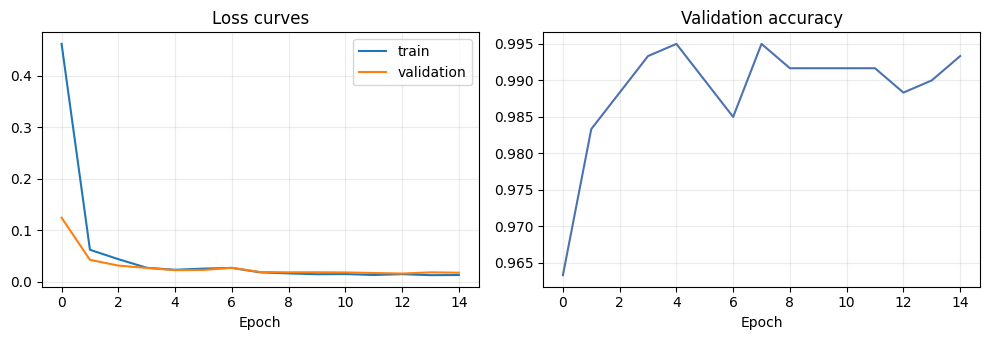

Best checkpoint saved to: checkpoints_native/best_storm_cnn.pt


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(state.history['train_loss'], label='train')
axes[0].plot(state.history['val_loss'], label='validation')
axes[0].set_title('Loss curves')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(state.history['val_accuracy'], color='#4c72b0')
axes[1].set_title('Validation accuracy')
axes[1].set_xlabel('Epoch')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f'Best checkpoint saved to: {checkpoint_dir / "best_storm_cnn.pt"}')


## Tracking Weight Norms

Callbacks are also a clean place to record model-health diagnostics that are not losses or accuracies. One useful example is the overall L2 norm of the weights.

If the weight norm grows very rapidly, it can be a sign that learning rates are too large or regularization is too weak. If it stays almost completely flat while the model is not learning, optimization may be stalled.


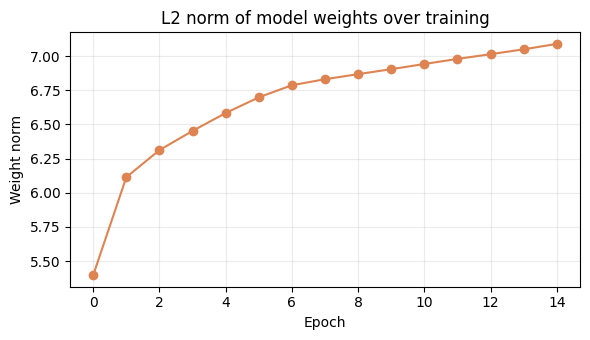

,epoch,weight_norm
0,1,5.397266
1,2,6.113996
2,3,6.312302
3,4,6.452740
4,5,6.583591


In [7]:
plt.figure(figsize=(6, 3.5))
plt.plot(state.history['weight_norm'], marker='o', color='#dd8452')
plt.title('L2 norm of model weights over training')
plt.xlabel('Epoch')
plt.ylabel('Weight norm')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

pd.DataFrame({
    'epoch': range(1, len(state.history['weight_norm']) + 1),
    'weight_norm': state.history['weight_norm'],
}).head()


**Why this pattern is worth keeping**

- The training loop still shows `forward`, `loss`, `backward`, and `step`.
- Side effects live in small callback classes instead of scattered `if` statements.
- The same pattern scales to logging, gradient clipping, model summaries, and periodic evaluation.

This is the right level of abstraction for a research notebook: structured enough to stay readable, but not so abstract that you lose track of what PyTorch is actually doing.
